<a href="https://colab.research.google.com/github/moronya/DL-Practice/blob/develop/BasketBall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [2]:
%pip install "ultralytics<=8.3.40"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 20.8 MB/s eta 0:00:00


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 32.5/112.6 GB disk)


In [4]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mjU0t7F1Imshyo7TDhm0")
project = rf.workspace("kfl").project("cv-cnfd4-fuhqw")
version = project.version(1)
dataset = version.download("yolov11")

/content/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to cv-1 in yolov11:: 100%|██████████| 7344/7344 [00:01<00:00, 5508.68it/s]


In [5]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 111MB/s]
New https://pypi.org/project/ultralytics/8.3.61 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/cv-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, 

In [6]:
!ls {HOME}/runs/detect/train/

args.yaml					    R_curve.png		  val_batch0_labels.jpg
confusion_matrix_normalized.png			    results.csv		  val_batch0_pred.jpg
confusion_matrix.png				    results.png		  val_batch1_labels.jpg
events.out.tfevents.1736820446.85b7d373adbd.1892.0  train_batch0.jpg	  val_batch1_pred.jpg
F1_curve.png					    train_batch14490.jpg  val_batch2_labels.jpg
labels_correlogram.jpg				    train_batch14491.jpg  val_batch2_pred.jpg
labels.jpg					    train_batch14492.jpg  weights
P_curve.png					    train_batch1.jpg
PR_curve.png					    train_batch2.jpg


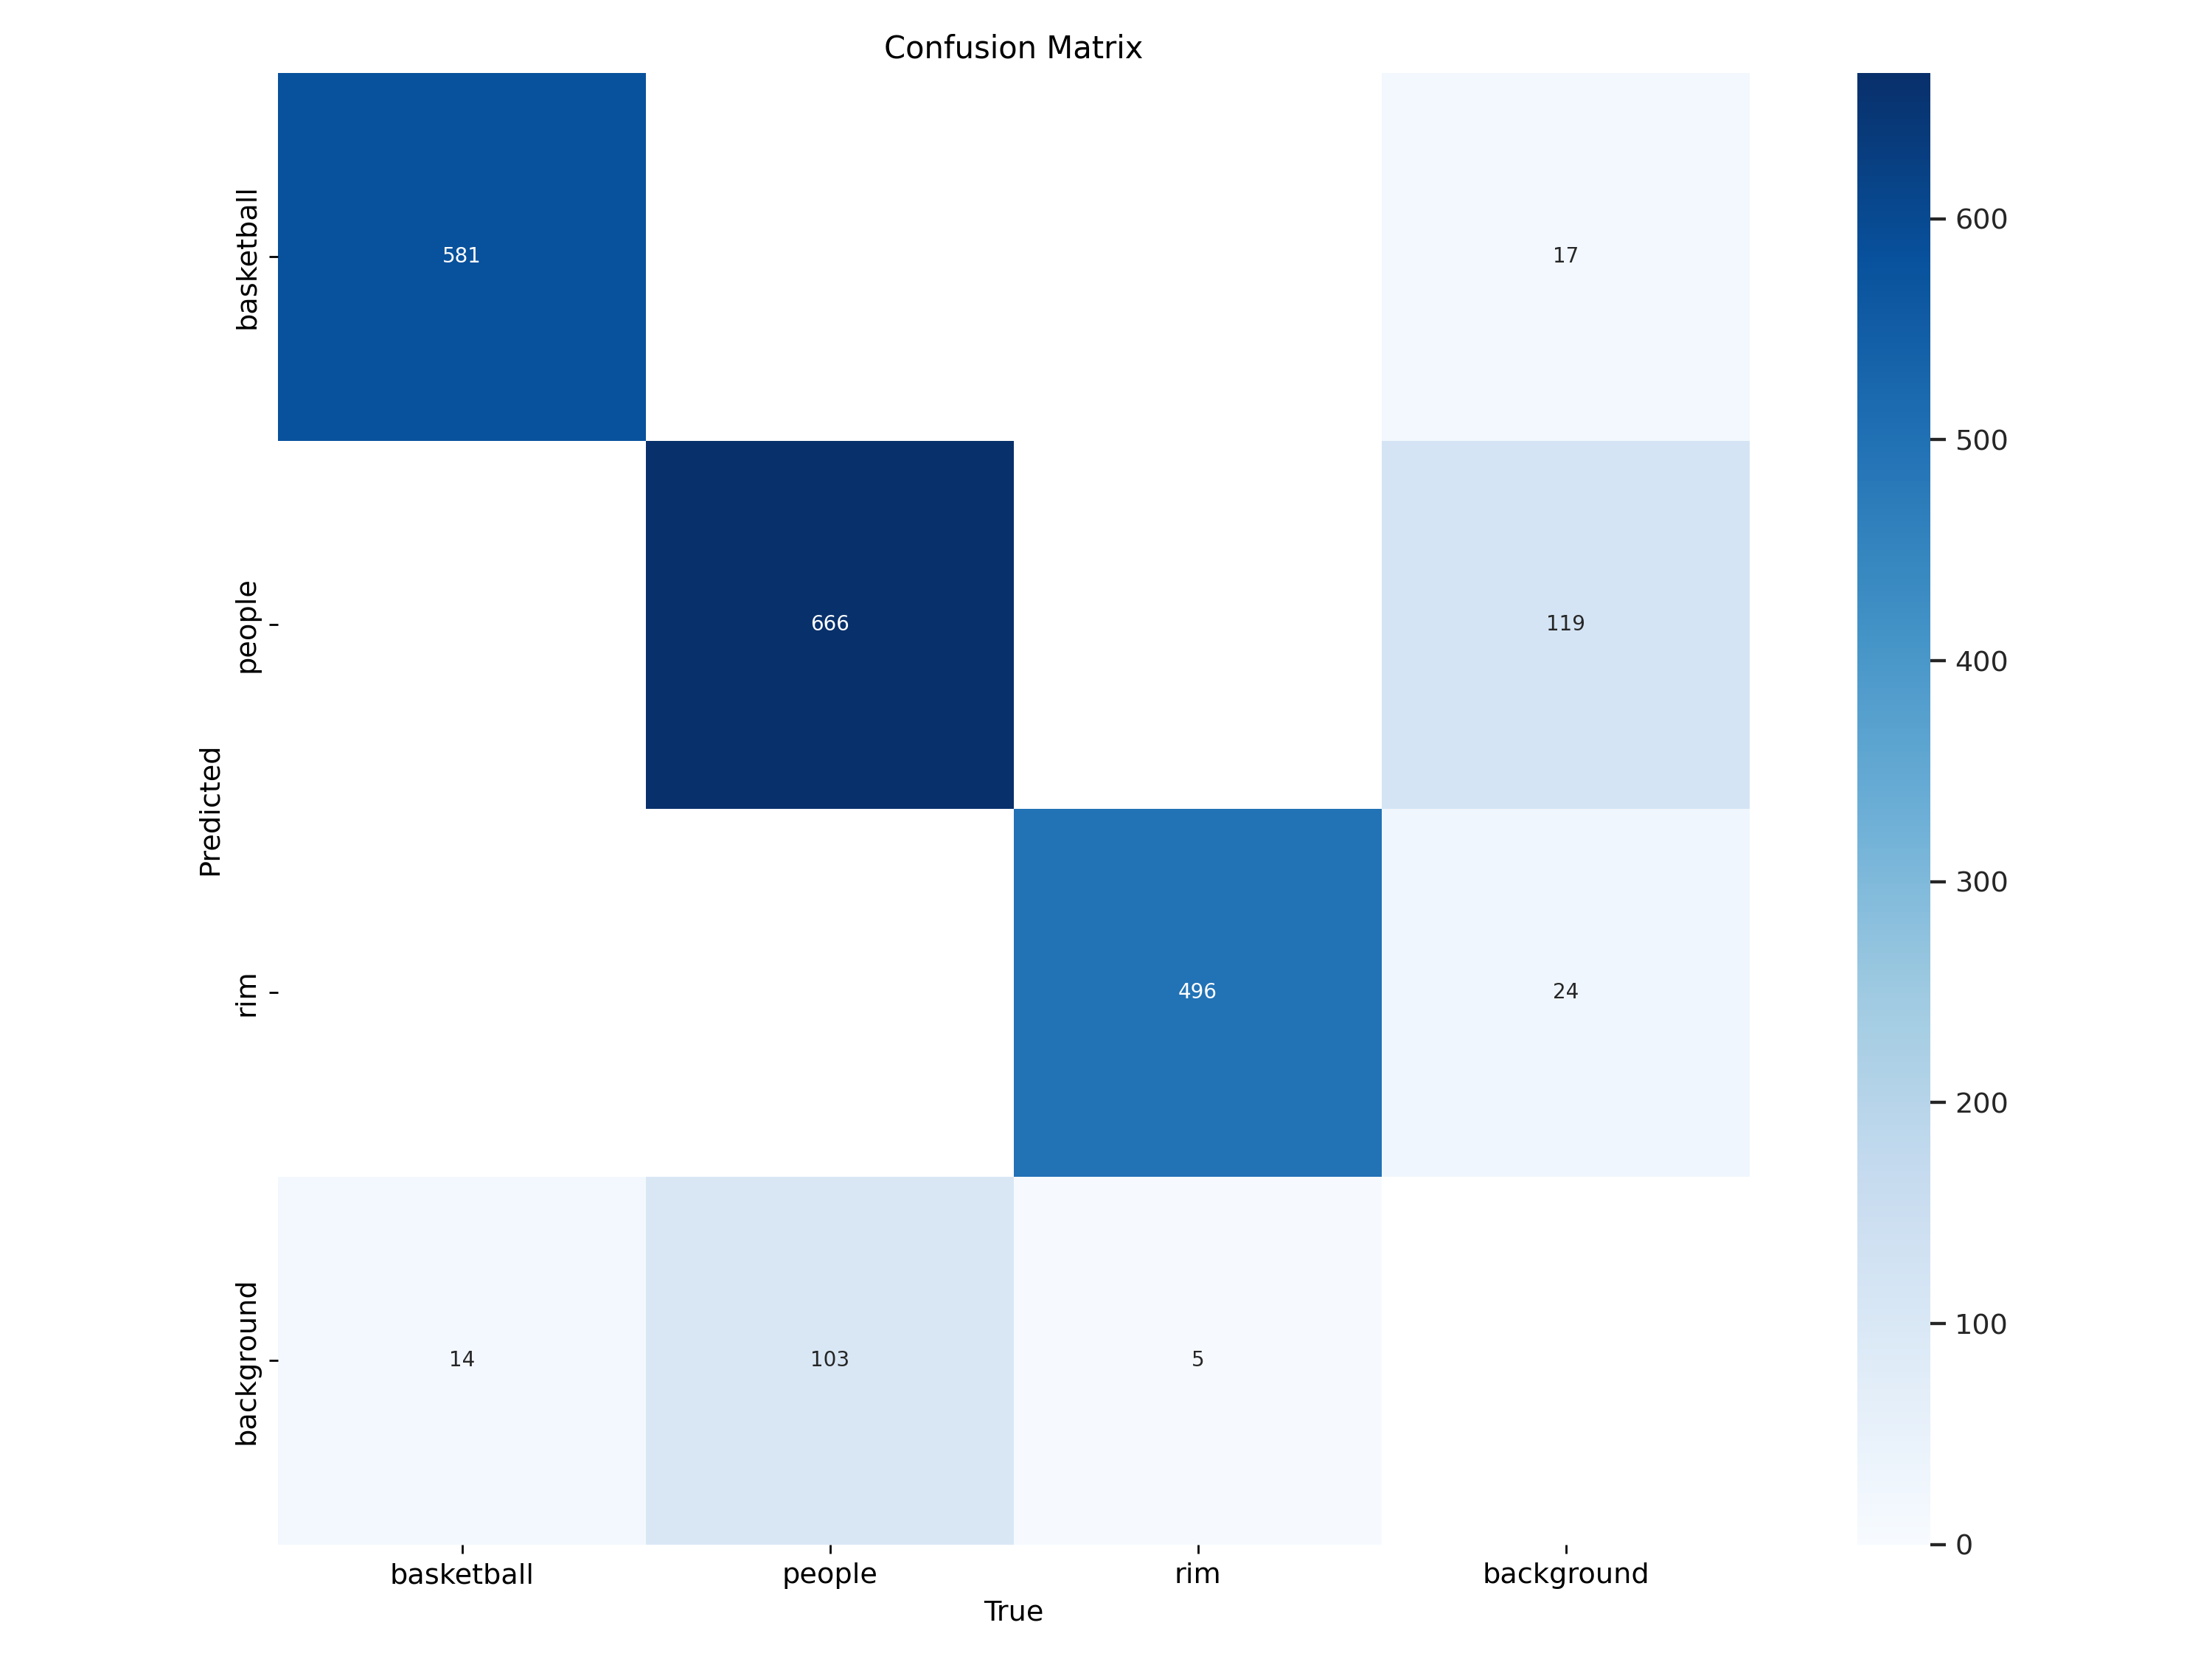

In [7]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

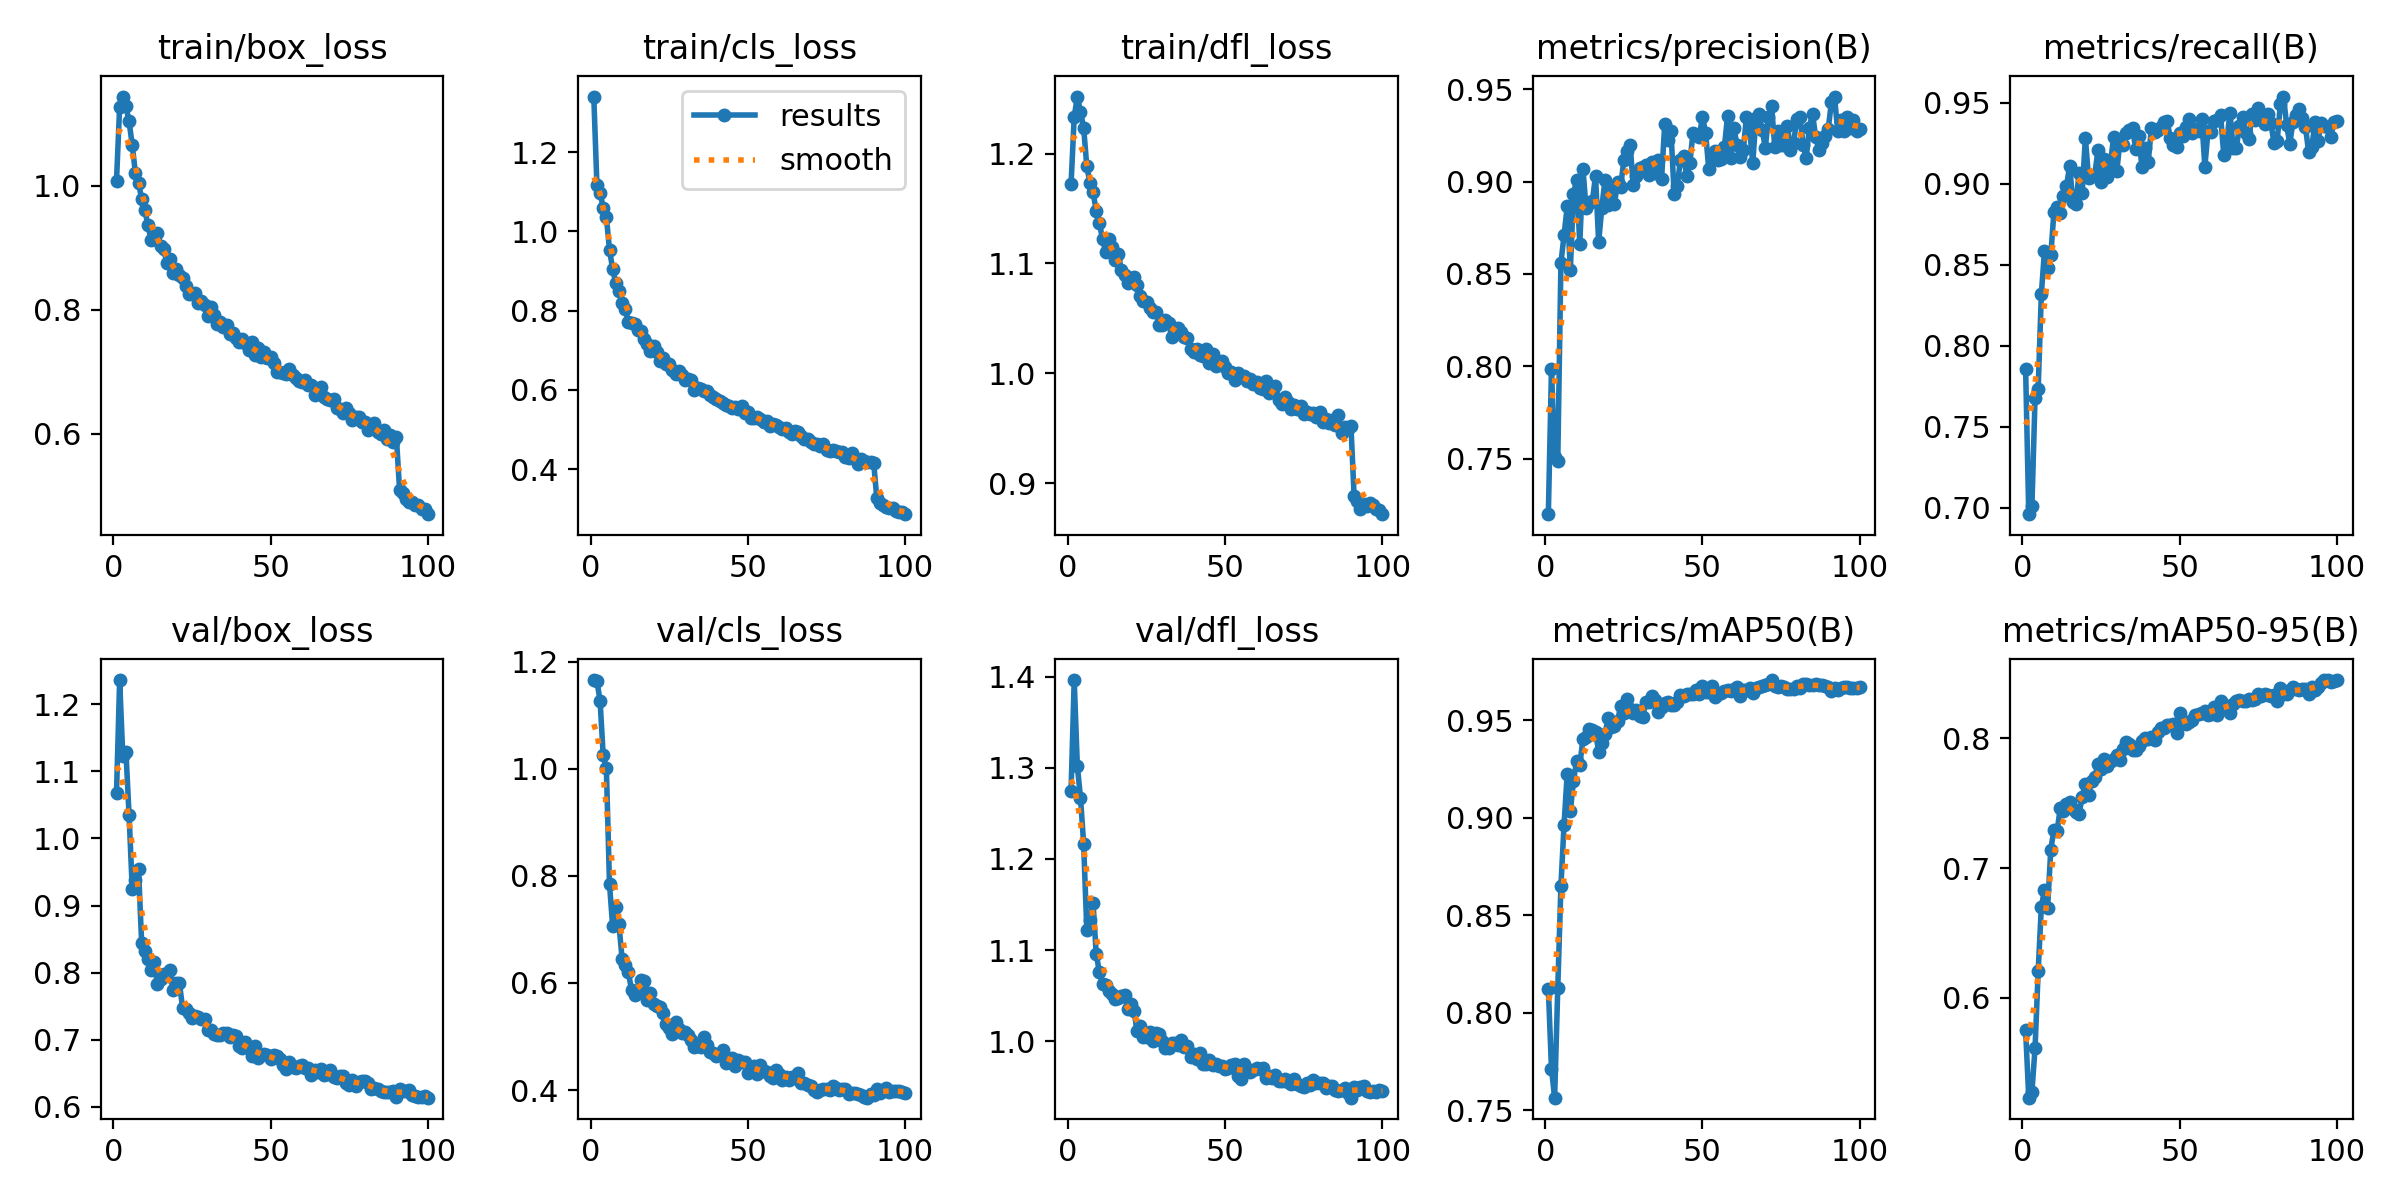

In [8]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

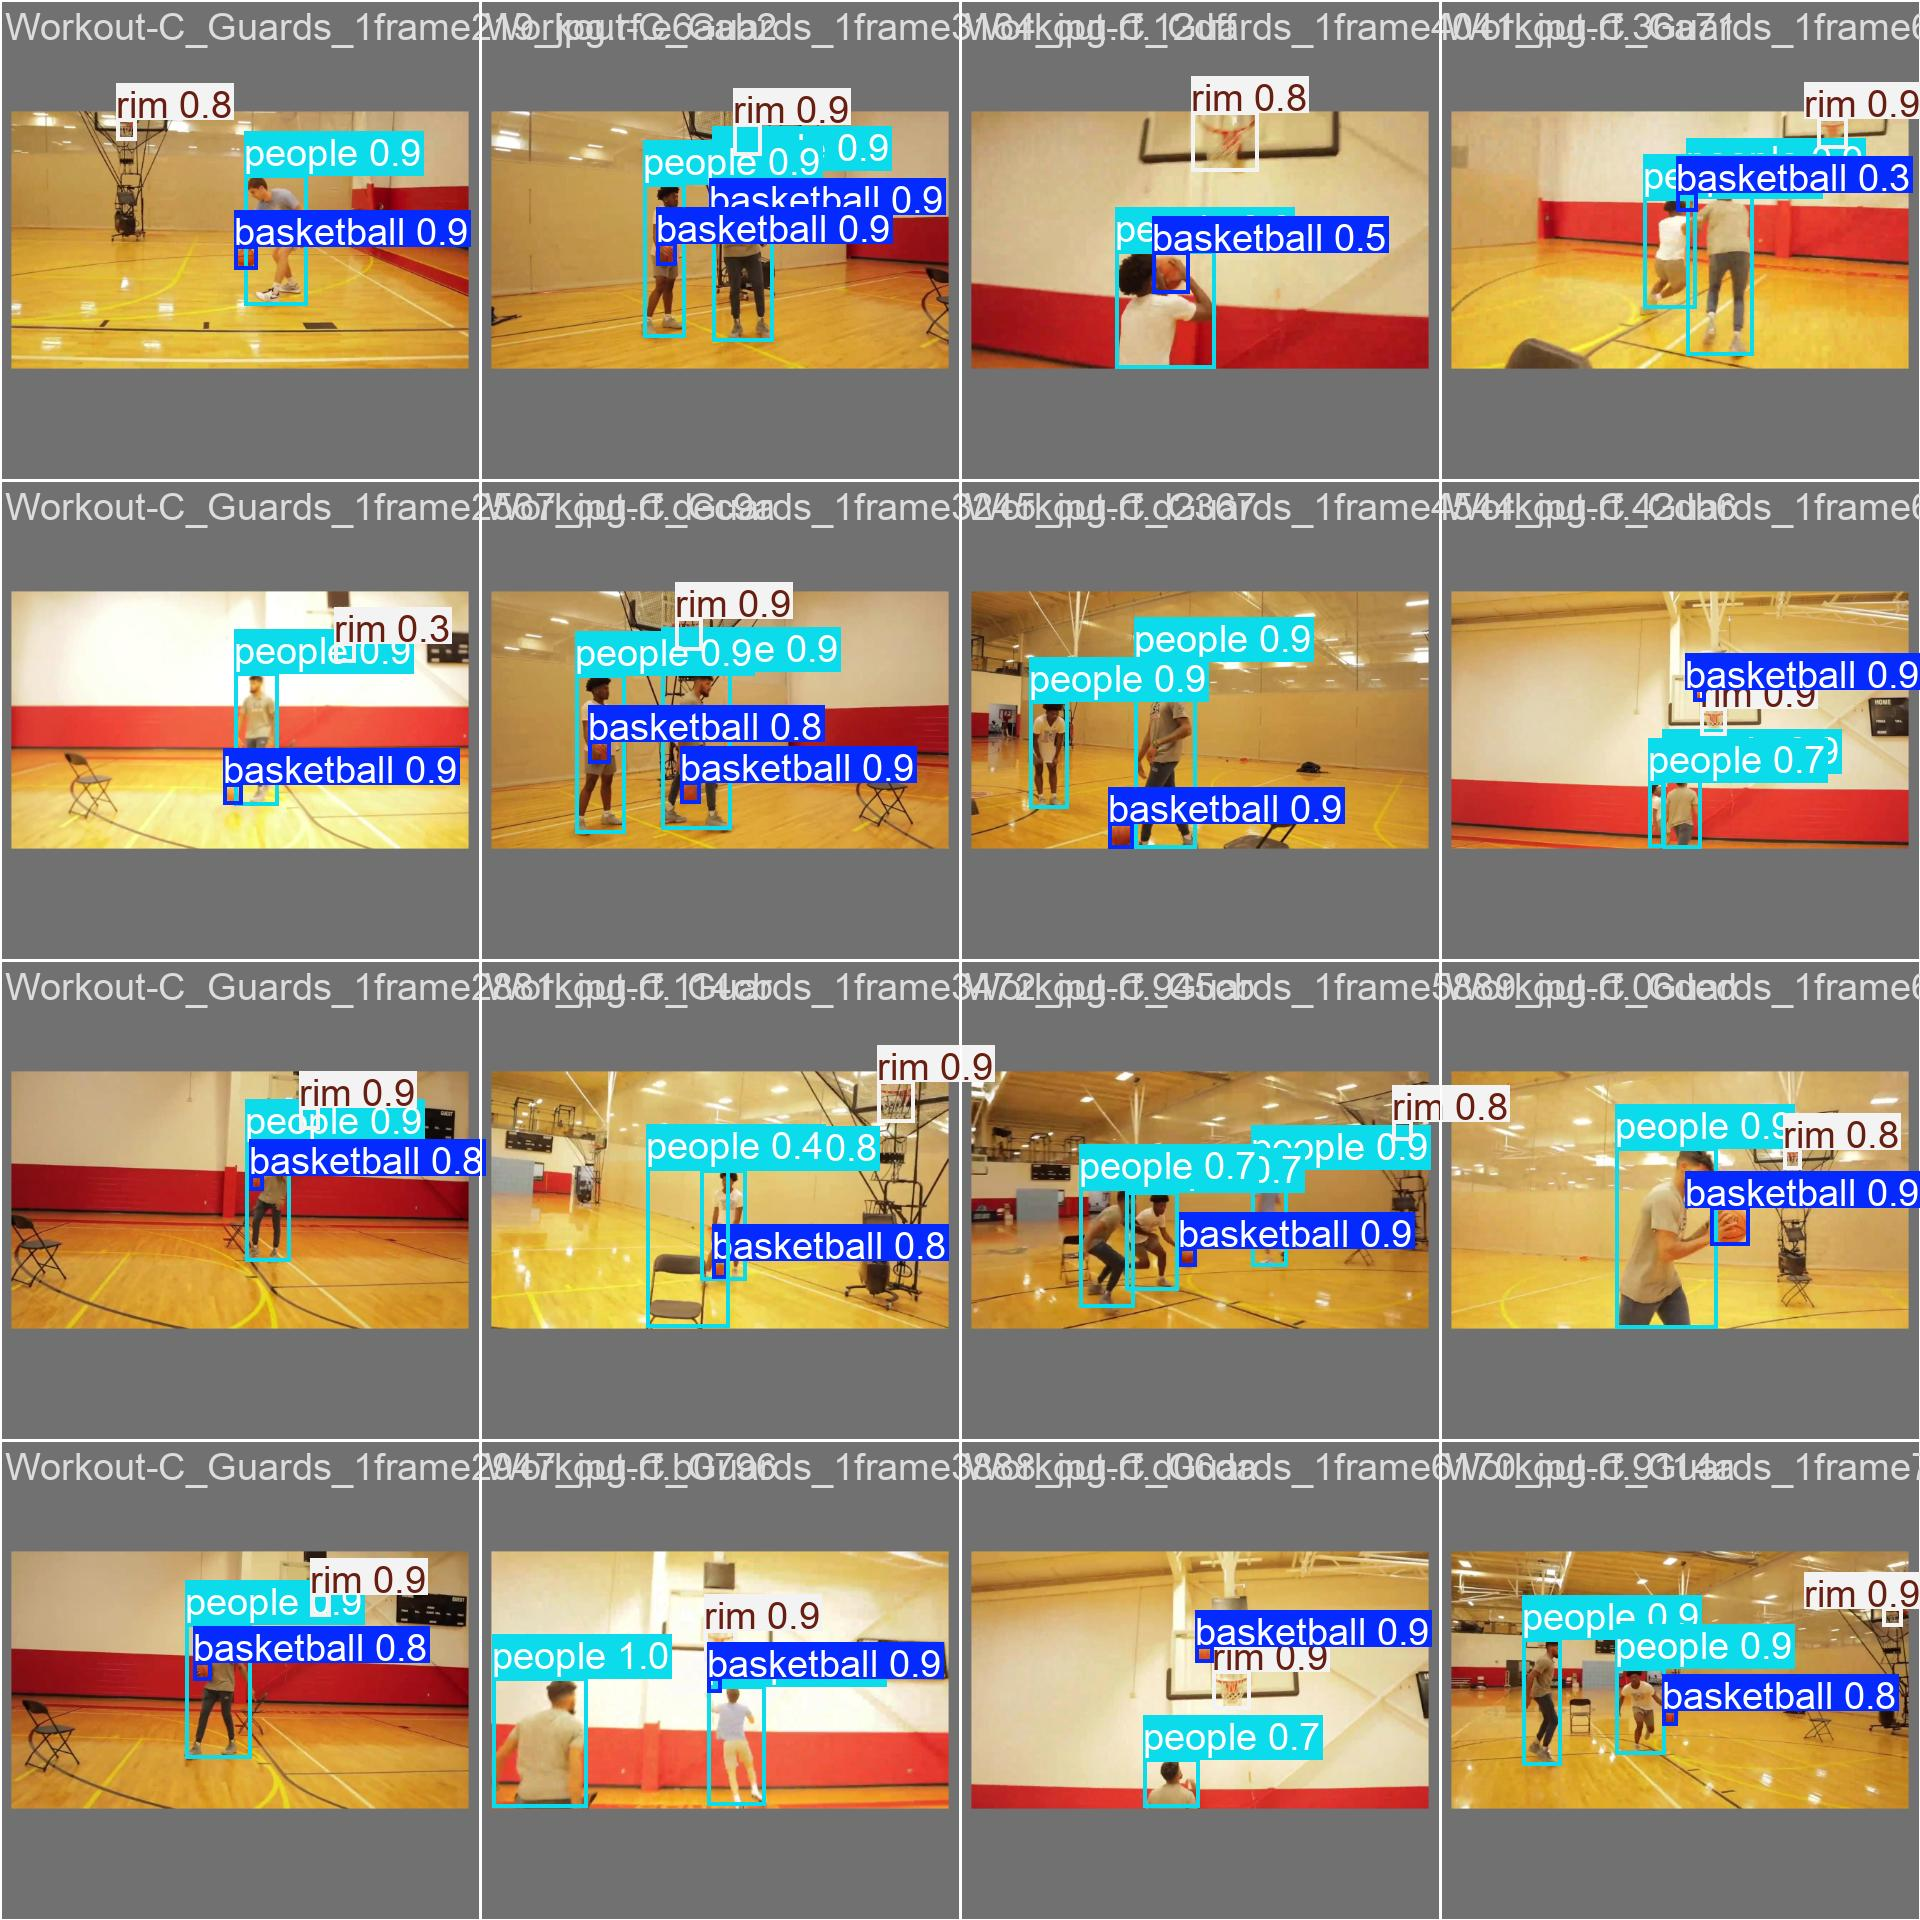

In [9]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [10]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11s summary (fused): 238 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/cv-1/valid/labels.cache... 733 images, 0 backgrounds, 0 corrupt: 100% 733/733 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 46/46 [00:11<00:00,  4.06it/s]
                   all        733       1865      0.935      0.933      0.967      0.846
            basketball        568        595      0.978      0.971      0.989      0.849
                people        428        769      0.863      0.838      0.922      0.758
                   rim        491        501      0.963      0.988       0.99       0.93
Speed: 0.4ms preprocess, 8.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [11]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11s summary (fused): 238 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs

image 1/367 /content/datasets/cv-1/test/images/000007_jpg.rf.eba9d62009635b045f0ef328af936559.jpg: 640x640 2 basketballs, 4 peoples, 1 rim, 15.6ms
image 2/367 /content/datasets/cv-1/test/images/000009_jpg.rf.3fda9843b672569da195e4dfeddeedf4.jpg: 640x640 6 peoples, 1 rim, 15.6ms
image 3/367 /content/datasets/cv-1/test/images/000010_jpg.rf.dfd1bdd6422a66bdecc2e957f984c53f.jpg: 640x640 1 basketball, 4 peoples, 15.6ms
image 4/367 /content/datasets/cv-1/test/images/000015_jpg.rf.63a3664f6d99bea8c080adf0c8902b85.jpg: 640x640 5 peoples, 15.5ms
image 5/367 /content/datasets/cv-1/test/images/000197_jpg.rf.8c34edf9a3a9c9ce50cc26c44e274a15.jpg: 640x640 1 basketball, 5 peoples, 1 rim, 15.5ms
image 6/367 /content/datasets/cv-1/test/images/000202_jpg.rf.2d138a737c4bde8565c01207f4fa6832.jpg: 640x640 1 basketball, 5 peoples, 1 rim, 15.6m